In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_results.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from pybaselines import Baseline
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
from PIXE_polygauss import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_results.ipynb started: Wed, 27 May 2026 12:06:45
INFO: SETUP COMPLETE (2046.88 ms)
---------------------------------------


In [3]:
# fine = True
# DPI = 400
# filename = './/collected_data//2026_05_13//20260513-060516.vspc'
# data = read_json_formatted_file(filename)
# meas_name = filename.split('//')[3].split('.')[0]
# meas_folder = filename.split('//')[2]

# energyPerBin = data['Calibration']['BinSize_keV/Bin'] # keV/bin
# bin_data = data['RawData'][:-1] #remove that overflow bin at position 8191
# total_counts = np.sum(bin_data)
# total_counts_incl = np.sum(data['RawData'])
# # print(bin_data)

# bins = np.arange(0,len(bin_data),1)

# scatter_color = color_schemes['c_dark']

# fig, ax = plt.subplots(figsize=(40,4), dpi=DPI)
# # ax.set_facecolor(color_schemes['c_back'])
# # ax.plot(bins, bin_data, lw=0.75, color=scatter_color[0], zorder=2)
# ax.step(bins, bin_data, lw=0.75, color=scatter_color[3], zorder=2)

# if (len(bin_data) == 8191):
#     ax.set_xlim(0,8193)
#     ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
#     if fine == True:
#        ax.set_xticks(np.arange(0,8193,64),np.arange(0,8193,64)) 
# elif (len(bin_data) == 4095):
#     ax.set_xlim(0,4095)
#     ax.set_xticks(np.arange(0,4097,512),np.arange(0,4097,512))
# elif (len(bin_data) == 2047):
#     ax.set_xlim(0,2047)
#     ax.set_xticks(np.arange(0,2049,512),np.arange(0,2049,512))


# secax = ax.secondary_xaxis('top')
# secax.set_xlim(0,8193)
# secax.set_xticks(np.arange(0,8193,64),list(np.arange(0,(8193*2.3866),(64*2.3866)).round(1)), rotation=30, ha='left')
# secax.set_xlabel('Energy / eV', fontsize=6)
    
# plt.xlabel('MCA channel')
# plt.ylabel('Counts')

# plt.yscale('log')

# plt.grid(which="both")
# plt.tight_layout()

# #----------------- Information Box -----------------#
# #det_pic_file = detector_pic(measurement['det_id'])
# # img = plt.imread(det_pic_file)
# annotation = TextArea(f"X-ray measurement \n {meas_name} \n RAW DATA \n Total Counts: {total_counts}", textprops=dict(color="black", fontsize=5, multialignment='center'))
# # imagebox = OffsetImage(img, zoom=0.05)
# stacked = VPacker(children=[annotation],
#                 align="center",
#                 pad=0,
#                 sep=5)

# ab = AnnotationBbox(offsetbox=stacked, xy=(0.9,0.85), xycoords='axes fraction', frameon=True)

# ax.add_artist(ab)
# #----------------- Information Box -----------------#


# plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_wide.png', dpi=DPI)
# plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_wide.pdf', dpi=DPI)

In [4]:
# f_n = all_files_from_measSet('2026_02_26')
# f_n = all_files_from_measSet('2026_02_27')
# f_n = all_files_from_measSet('2026_03_25')
# f_n = all_files_from_measSet('collected_data//2026_05_13')

In [3]:
def data_baseline(bin_data:list, bins:list):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.arpls(bin_data, lam=1e2, max_iter=400)
    subtracted = bin_data - baseline
    return baseline, subtracted

def data_baseline_subtracted(file:str, select_window:list):
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bin_data_selected = bin_data[select_window[0]:select_window[1]+1]
    bin_data_zerofixed = np.where(bin_data_selected == 0, 1, bin_data_selected)
    data_err = np.sqrt(bin_data_zerofixed)
    
    bins = np.arange(0,len(bin_data),1)
    bins_selected = bins[select_window[0]:select_window[1]+1]
    bins_err = np.array([2]*len(bins))
    
    bl_full, sub_full = data_baseline(bin_data, bins)
    bl_sw, sub_sw = data_baseline(bin_data_selected, bins_selected)
    
    g_sum_full = np.sum(sub_full[1030:1080])
    g_sum_sw = np.sum(sub_sw[30:80])
    
    print('Spectrum Full:', g_sum_full)
    print('Spectrum SW:', g_sum_sw)
    print('Difference Full:',np.sum(bin_data[1030:1080]) - g_sum_full, (np.sum(bin_data[1030:1080]) - g_sum_full)/np.sum(bin_data[1030:1080]))
    print('Difference SW:',np.sum(bin_data[1030:1080]) - g_sum_sw, (np.sum(bin_data[1030:1080]) - g_sum_sw)/np.sum(bin_data[1030:1080]))
    
    
    plt.figure(figsize=(6,3), dpi=300)
    plt.step(bins, bin_data, alpha=1, lw=0.5, color=color_schemes['c_rainbow'][0], label='Original Spectrum')
    plt.plot(bins, bl_full, alpha=0.8, lw=0.8, ls='-.', color=color_schemes['c_rainbow'][1], label='Baseline')
    plt.step(bins, sub_full, lw=0.5, color=color_schemes['c_rainbow'][5], label='Baseline subtracted spectrum')
    
    plt.plot(bins_selected, bl_sw, lw=0.8, alpha=0.8, ls='-.', color=color_schemes['c_rainbow'][2], label='Baseline selected window')
    plt.step(bins_selected, sub_sw, lw=0.5, color=color_schemes['c_rainbow'][6], label='Baseline subtracted spectrum selected window')
    
    # plt.yscale('log')
    
    plt.xlabel(r'MCA channel $N_{\mathrm{c}}$')
    plt.ylabel('Counts')
    
    plt.ylim(0,7500)
    plt.xlim(select_window[0],select_window[1])
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'./plots/{file.split('//')[-1].split('.')[0]}_0_arplsBaselineSubstracted.png', transparent=False, dpi=300)
    

# data_baseline_subtracted('.//collected_data//2026_05_13//20260513-160638.vspc', [1000,1200])

In [4]:
def peak_fitter(file:str, init_values:list, gauss_ident:str,
                select_window:list, xlim:list,
                substract_flag:bool = False, region_flag:str = 'roi_x'):
    
    data = read_json_formatted_file(file)
    
    offset_start = select_window[0] - xlim[0]
    offset_end = select_window[1] - xlim[0] + 1
    
    bin_data = np.array(data['RawData'][:-1])
    bin_data_selwindow = bin_data[select_window[0]:select_window[1]+1]
    bin_data_xlim = bin_data[xlim[0]:xlim[1]+1]
    
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    
    
    bins = np.arange(0,len(bin_data),1)
    bins_selwindow = bins[select_window[0]:select_window[1]+1]
    bins_xlim = bins[xlim[0]:xlim[1]+1]
    
    data_err = np.sqrt(bin_data_zerofixed)
    bins_err = np.array([2]*len(bins_selwindow))
    
    bl, subtr_data = data_baseline(bin_data_xlim, bins_xlim)
    bl, subtr_data_fit = data_baseline(bin_data_selwindow, bins_selwindow)
    bl, subtr_data_full = data_baseline(bin_data, bins)
    
    # roi_x: arPLS in xlim, fit in select_window
    # roi_f: arPLS in select_window, fit in select_window
    # roi_t; arPLS in full data, fit in select_window
    if (substract_flag == True):
        if (region_flag == 'roi_x'):
            if (gauss_ident == 'single'):
                beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
                            x=bins_selwindow, y=subtr_data[offset_start:offset_end], xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
            elif (gauss_ident == 'double'):
                beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
                            x=bins_selwindow, y=subtr_data[offset_start:offset_end], xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
            elif (gauss_ident == 'multi'):
                beta = evaluator_scipy(func=multi_gauss, beta0_list=init_values,
                            x=bins_selwindow, y=subtr_data[offset_start:offset_end], xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
            return beta, subtr_data
        elif (region_flag == 'roi_f'):
            if (gauss_ident == 'single'):
                beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
                            x=bins_selwindow, y=subtr_data_fit, xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
            elif (gauss_ident == 'double'):
                beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
                            x=bins_selwindow, y=subtr_data_fit, xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
            elif (gauss_ident == 'multi'):
                beta = evaluator_scipy(func=multi_gauss, beta0_list=init_values,
                            x=bins_selwindow, y=subtr_data_fit, xerr=bins_err, yerr=data_err[select_window[0]:select_window[1]+1])
            return beta, subtr_data_fit
        elif (region_flag == 'roi_t'):
            if (gauss_ident == 'single'):
                beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
                            x=bins, y=subtr_data_full, xerr=np.array([2]*len(bins)), yerr=data_err)
            elif (gauss_ident == 'double'):
                beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
                            x=bins, y=subtr_data_full, xerr=np.array([2]*len(bins)), yerr=data_err)
            elif (gauss_ident == 'multi'):
                beta = evaluator_scipy(func=multi_gauss, beta0_list=init_values,
                            x=bins, y=subtr_data_full, xerr=np.array([2]*len(bins)), yerr=data_err)
            return beta, subtr_data_full
    

In [5]:
def all_peaks_one_measurement(file:str, peaks:list, xlim:list, ylim:list, info:list, col_flag:bool, identifier:str, gauss_ident:list):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_complementary']
        gcp = [0,3,4,5,6,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    meas_name = file.split('//')[3].split('.')[0]
    meas_folder = file.split('//')[2]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]}')
    # plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
        beta= peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p])
        beta_export = [beta['param'],beta['errors']]
        
        
        if (gauss_ident[p] == 'single'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'double'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][4]*1.05)
            plt.plot(bins[gauss_left:gauss_right],double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][:3], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][3:], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.fill_between(x=bins[gauss_left:gauss_right],y1=double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),alpha=0.4, color=gauss_color[gcp[p]], zorder=2, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'single_lin'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_linear_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
              
        
            
        csv_file_name = f'.//peak_idents//{meas_folder}//{meas_name}_peaks_{identifier}.csv'
        
        with open(csv_file_name, mode='a', newline='', encoding='utf-8') as csv_file:
            writer = csv.writer(csv_file)
            writer.writerows(beta_export)
        
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    if (ylim != []):
        plt.ylim(ylim[0],ylim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

In [57]:
def fit_result_printer(beta:dict, roi_x:list, roi_fit:list, gauss_type:str, r_flag:str):
    param = beta['param']
    errors = beta['errors']
    
    print('=========== REGION of INTEREST ===========')
    if (r_flag == 'roi_t'):
        print(f'\u21e8 full MCA selection:'.ljust(26) + '[   0, 8190]'.ljust(15))
    else:
        print(f'full MCA selection:'.ljust(25) + '[   0, 8190]'.ljust(15))
    if (r_flag == 'roi_x'):
        print(f'\u21e8 x-axis selection:'.ljust(26) + f'{roi_x}'.ljust(15))
    else:
        print(f'x-axis selection:'.ljust(25) + f'{roi_x}'.ljust(15))
    if (r_flag == 'roi_f'):
        print(f'\u21e8 fit window selection:'.ljust(26) + f'{roi_fit}'.ljust(15))
    else:
        print(f'fit window selection:'.ljust(25) + f'{roi_fit}'.ljust(15))
    print('=========== REGION of INTEREST ===========')
        
    print('\n')
        
    if (gauss_type == 's'):
        print('=========== FIT RESULTS ===========')
        print(f'Height:'.ljust(7) + f' {param[0]:.3f}'.rjust(10) +  f' \u00B1 {errors[0]:.3f}')
        print(f'Center:'.ljust(7) + f' {param[1]:.3f}'.rjust(10) +  f' \u00B1 {errors[1]:.3f}')
        print(f'Width:'.ljust(7)  + f'{param[2]:.3f}'.rjust(10)  +  f' \u00B1 {errors[2]:.3f}')
        print(f'FWHM:'.ljust(7)   + f'{param[2]*(2*np.log(2)):.3f}'.rjust(10) +  f' \u00B1 {errors[2]*(2*np.log(2)):.3f}')
        print('=========== FIT RESULTS ===========')
    elif (gauss_type == 'd'):
        print('=========== FIT RESULTS 1 of 2 ===========')
        print(f'Height A:'.ljust(9) + f' {param[0]:.3f}'.rjust(10) +  f' \u00B1 {errors[0]:.3f}')
        print(f'Center A:'.ljust(9) + f' {param[1]:.3f}'.rjust(10) +  f' \u00B1 {errors[1]:.3f}')
        print(f'Width A:'.ljust(9)  + f'{param[2]:.3f}'.rjust(10)  +  f' \u00B1 {errors[2]:.3f}')
        print(f'FWHM A:'.ljust(9)   + f'{param[2]*(2*np.log(2)):.3f}'.rjust(10) +  f' \u00B1 {errors[2]*(2*np.log(2)):.3f}')
        print('=========== FIT RESULTS 2 of 2 ===========')
        print(f'Height B:'.ljust(9) + f' {param[3]:.3f}'.rjust(10) +  f' \u00B1 {errors[3]:.3f}')
        print(f'Center B:'.ljust(9) + f' {param[4]:.3f}'.rjust(10) +  f' \u00B1 {errors[4]:.3f}')
        print(f'Width B:'.ljust(9)  + f'{param[5]:.3f}'.rjust(10)  +  f' \u00B1 {errors[5]:.3f}')
        print(f'FWHM B:'.ljust(9)   + f'{param[5]*(2*np.log(2)):.3f}'.rjust(10) +  f' \u00B1 {errors[5]*(2*np.log(2)):.3f}')
        print('=========== END of FIT RESULTS ===========')
    elif (gauss_type == 'm'):
        for i in range(0,len(param),3):
            res_id = int(i/3 + 1)
            print(f'=========== FIT RESULTS {res_id} of {int(len(param)/3)} ===========')
            print(f'Height {res_id}:'.ljust(9) + f' {param[i]:.3f}'.rjust(10) +  f' \u00B1 {errors[i]:.3f}')
            print(f'Center {res_id}:'.ljust(9) + f' {param[i+1]:.3f}'.rjust(10) +  f' \u00B1 {errors[i+1]:.3f}')
            print(f'Width {res_id}:'.ljust(9)  + f'{param[i+2]:.3f}'.rjust(10)  +  f' \u00B1 {errors[i+2]:.3f}')
            print(f'FWHM {res_id}:'.ljust(9)   + f'{param[i+2]*(2*np.sqrt(2*np.log(2))):.3f}'.rjust(10) +  f' \u00B1 {errors[i+2]*(2*np.sqrt(2*np.log(2))):.3f}')
        print('=========== END of FIT RESULTS ===========')

In [58]:
def fit_param_to_energy(param:list,ecal:list):
    energy = []
    for i in range(0,len(param),3):
        height = param[i]
        center = param[i+1]
        width  = param[i+2]
        fwhm = width * 2*np.sqrt(2*np.log(2))
        
        ecal_dc = ecal[0]
        ecal_dc_err = ecal[3]
        
        ecal_lin = ecal[1]
        ecal_lin_err = ecal[4]
        
        ecal_sq = ecal[2]
        ecal_sq_err = ecal[5]
        
        energy.append(height)
        energy.append(ecal_dc + center*ecal_lin + center**2*ecal_sq)
        energy.append(ecal_dc_err + center*ecal_lin_err + center**2*ecal_sq_err)
        energy.append(width*ecal_lin + width**2*ecal_sq)
        energy.append(width*ecal_lin_err + width**2*ecal_sq_err)
        energy.append(fwhm*ecal_lin + fwhm**2*ecal_sq)
        energy.append(fwhm*ecal_lin_err + fwhm**2*ecal_sq_err)
    
    return energy

ecalHWs = [239,7.471,1.467e-5,56.68,0.061,0.795e-5]

def energy_printer(energy:list):
    for i in range(0,len(energy),7):
        print('-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_')
        print(f'Height: {energy[i]:.3f}')
        print(f'Center: {energy[i+1]:.3f} \u00b1 {energy[i+2]:.3f}')
        print(f'Width: {energy[i+3]:.3f} \u00b1 {energy[i+4]:.3f}')
        print(f'FWHM: {energy[i+5]:.3f} \u00b1 {energy[i+6]:.3f}')
    

In [59]:
def find_selection_window(peaks,bin_grad,gauss_type):
    if (gauss_type == 's'):
        start_idx = peaks[1]
        #LEFT
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                # print('L:',closest_idx_left)
                break
        #RIGHT
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                # print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
        
    elif (gauss_type == 'd'):
        #LEFT
        start_idx = np.min([peaks[1],peaks[4]])
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                # print('L:',closest_idx_left)
                break
        #RIGHT
        start_idx = np.max([peaks[1],peaks[4]])
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                # print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
    
    elif (gauss_type == 'm'):
        #LEFT
        start_idx = np.min([peaks[1],peaks[-2]])
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                # print('L:',closest_idx_left)
                break
        #RIGHT
        start_idx = np.max([peaks[1],peaks[-2]])
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                # print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
        
    return select_window

def selection_fitter_plotter(file:str, peaks:list,
                             xlim:list, ylim:list,
                             info:list, col_flag:bool,
                             identifier:str, gauss_ident:list,
                             s_flag:bool=False, r_flag:str='roi_fit'):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_complementary']
        gcp = [0,3,4,5,6,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_grad = np.gradient(bin_data)
    meas_name = file.split('//')[3].split('.')[0]
    meas_folder = file.split('//')[2]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.step(bins, bin_data, lw=0.5, alpha=0.5, color='black', zorder=3, label='unsubtracted data')
    # plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
               
        if (gauss_ident[p] == 'single'): 
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='s')
            plt.fill_betweenx(y=[0,peaks[p][0]],x1=select_window[0],x2=select_window[1],color=gauss_color[gcp[p]], zorder=2, alpha=0.15, lw=0.1, label='selection window')
            
            beta, sub_sw = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag)
            
            fit_result_printer(beta=beta, roi_x=xlim, roi_fit=select_window, gauss_type='s', r_flag=r_flag)
            
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            
            
            plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=0.8, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'double'):
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='d')
            plt.fill_betweenx(y=[0,np.max([peaks[p][0],peaks[p][3]])],x1=select_window[0],x2=select_window[1],color=gauss_color[gcp[p]], zorder=2, alpha=0.15, lw=0.1, label='selection window')
            
            beta, sub_sw = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag)
            
            fit_result_printer(beta=beta, roi_x=xlim, roi_fit=select_window, gauss_type='d', r_flag=r_flag)
            
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][4]*1.05)
            
            plt.plot(bins[gauss_left:gauss_right],double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=0.8, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][:3], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][3:], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.fill_between(x=bins[gauss_left:gauss_right],y1=double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),alpha=0.4, color=gauss_color[gcp[p]], zorder=2, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'multi'):
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='m')
            plt.fill_betweenx(y=[0,np.max([peaks[p][i] for i in range(0,len(peaks[p]),3)])*1.05],x1=select_window[0],x2=select_window[1],color=gauss_color[gcp[p]], zorder=2, alpha=0.15, lw=0.1, label='selection window')
            
            beta, sub_sw = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window, xlim=xlim, substract_flag=s_flag, region_flag=r_flag)
        
            fit_result_printer(beta=beta, roi_x=xlim, roi_fit=select_window, gauss_type='m', r_flag=r_flag)
            energy_list = fit_param_to_energy(param=beta['param'],ecal=ecalHWs)
            energy_printer(energy_list)
            
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][-2]*1.05)
            
            plt.plot(bins[gauss_left:gauss_right],multi_gauss(beta['param'], bins[gauss_left:gauss_right]),lw=0.8, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        
    if (s_flag == True and r_flag == 'roi_x'):
        plt.step(bins[xlim[0]:xlim[1]+1], sub_sw, lw=1, color='black', zorder=2, label=f'baseline subtracted data')
    elif (s_flag == True and r_flag == 'roi_f'):
        plt.step(bins[select_window[0]:select_window[1]+1], sub_sw, lw=1, color='black', zorder=2, label=f'baseline subtracted data')
    elif (s_flag == True and r_flag == 'roi_t'):
        plt.step(bins, sub_sw, lw=1, color='black', zorder=2, label=f'baseline subtracted data')
            
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    if (ylim != []):
        plt.ylim(ylim[0],ylim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

## 3400 (~7.6 eV/MCA) @ 8192 10h

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
⇨ x-axis selection:       [1700, 1950]   
fit window selection:    [1737, 1905]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 3 ===========
Height 1: 11582.707 ± 38.308
Center 1:  1792.596 ± 0.191
Width 1:     13.895 ± 0.116
FWHM 1:      32.720 ± 0.273
=========== FIT RESULTS 2 of 3 ===========
Height 2: 52829.613 ± 170.459
Center 2:  1833.554 ± 0.138
Width 2:     11.393 ± 0.083
FWHM 2:      26.829 ± 0.196
=========== FIT RESULTS 3 of 3 ===========
Height 3:  2096.161 ± 18.231
Center 3:  1877.114 ± 0.206
Width 3:      9.392 ± 0.157
FWHM 3:      22.116 ± 0.369
=========== END of FIT RESULTS ===========
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Height: 11582.707
Center: 13678.623 ± 191.575
Width: 103.813 ± 0.849
FWHM: 244.469 ± 2.004
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Height: 52829.613
Center: 13986.805 ± 195.254
Width: 85.122 ± 0.696
FWHM: 200.4

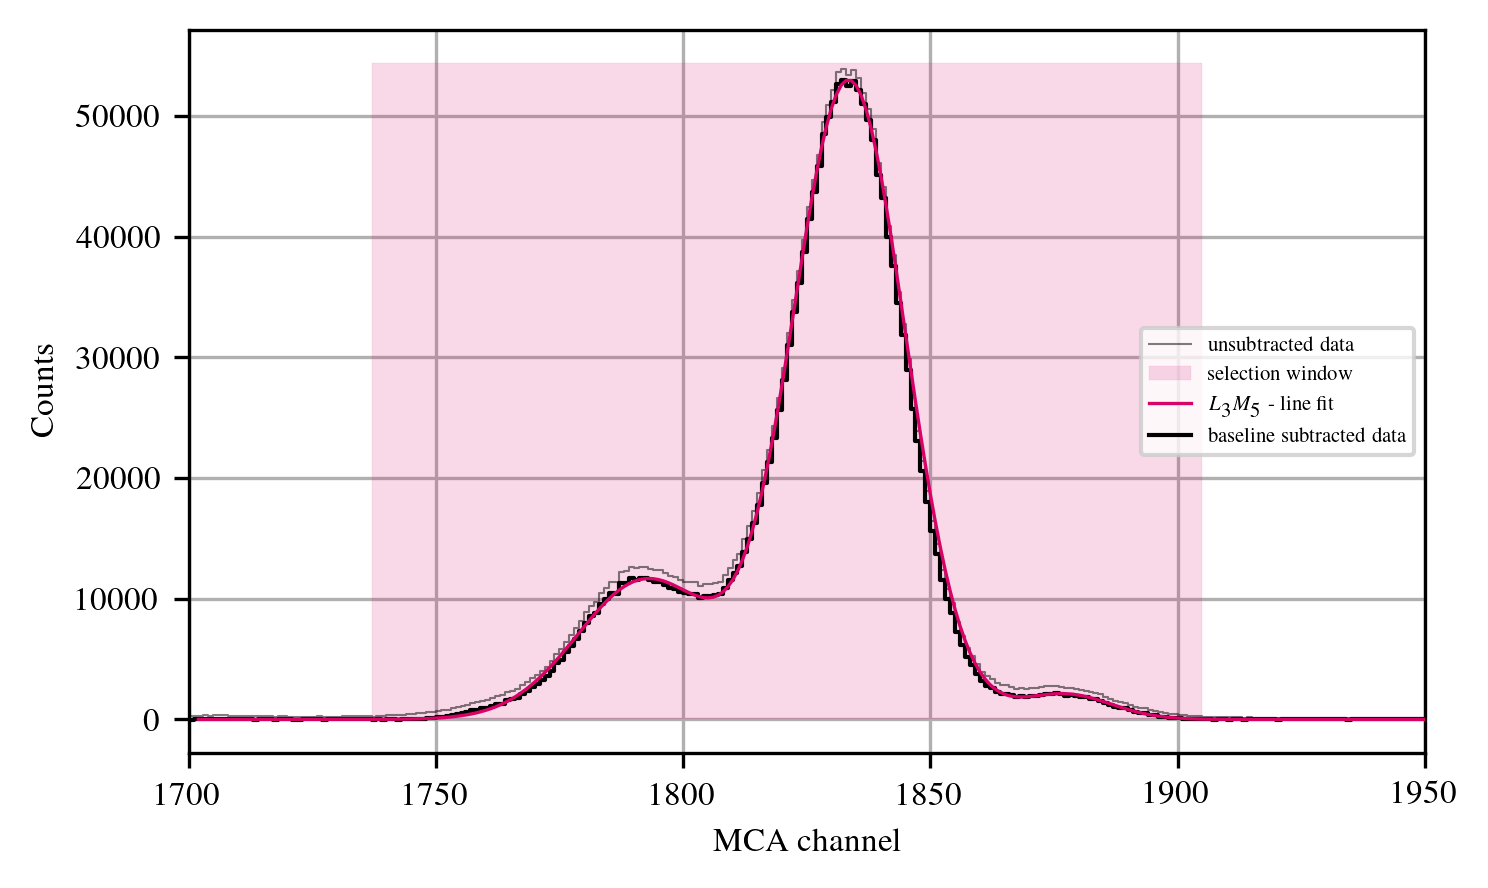

=========== REGION of INTEREST ===========
full MCA selection:      [   0, 8190]   
x-axis selection:        [1700, 1950]   
⇨ fit window selection:   [1737, 1905]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 3 ===========
Height 1:  4503.860 ± 196.824
Center 1:  1787.610 ± 0.355
Width 1:      6.343 ± 0.251
FWHM 1:      14.936 ± 0.592
=========== FIT RESULTS 2 of 3 ===========
Height 2: 47177.398 ± 1291.417
Center 2:  1834.488 ± 0.274
Width 2:      8.530 ± 0.156
FWHM 2:      20.086 ± 0.367
=========== FIT RESULTS 3 of 3 ===========
Height 3:  1112.059 ± 71.188
Center 3:  1881.194 ± 0.397
Width 3:      5.650 ± 0.305
FWHM 3:      13.304 ± 0.718
=========== END of FIT RESULTS ===========
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Height: 4503.860
Center: 13641.112 ± 191.129
Width: 47.388 ± 0.387
FWHM: 111.593 ± 0.913
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Height: 47177.398
Center: 13993.827 ± 195.338
Width: 63.728 ± 0.521
FWHM: 150.0

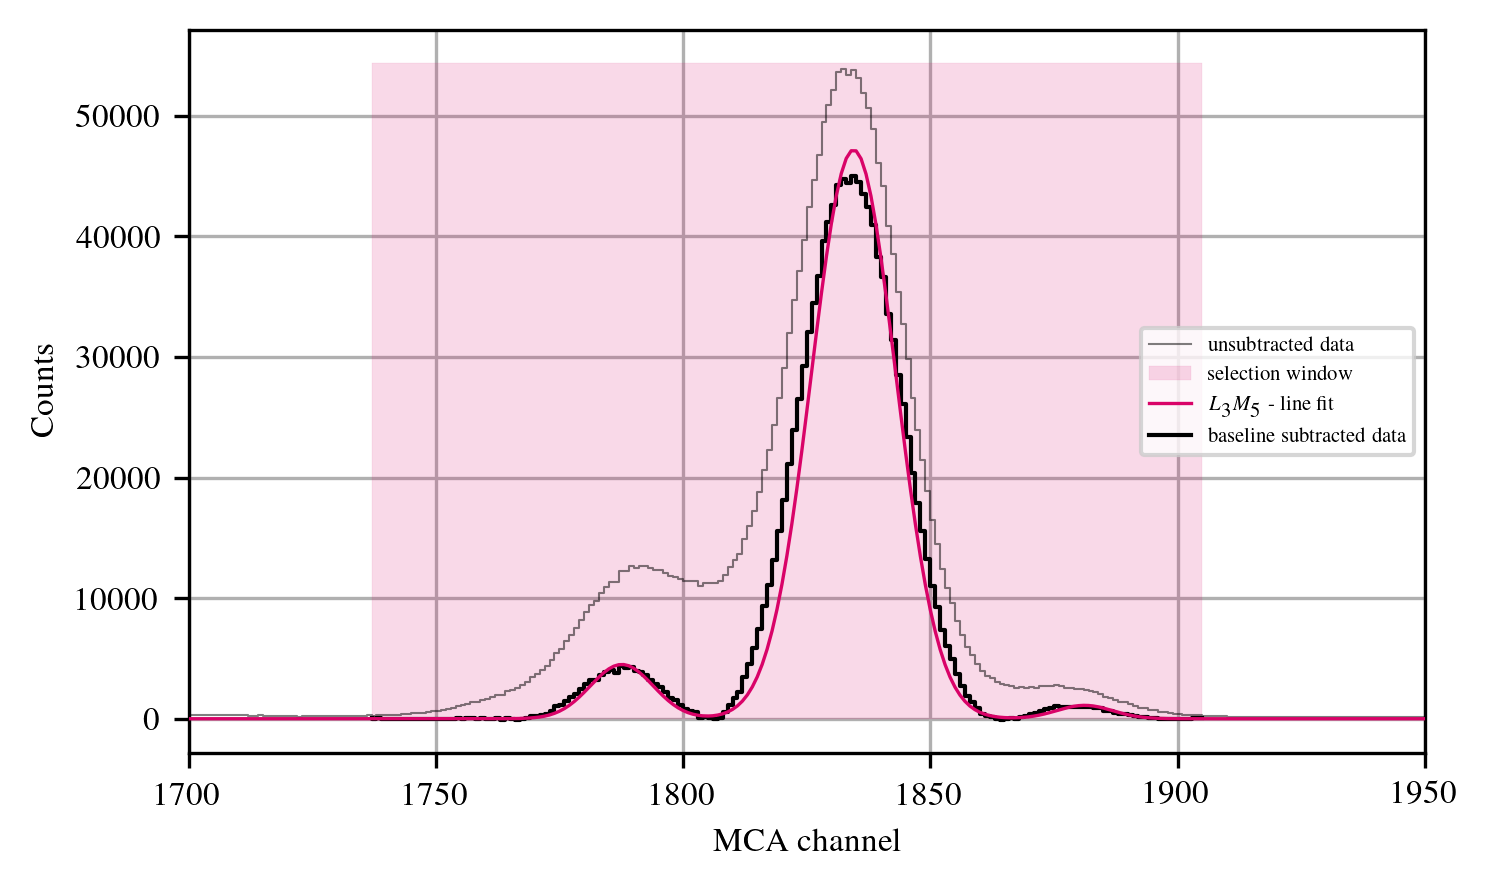

=========== REGION of INTEREST ===========
⇨ full MCA selection:     [   0, 8190]   
x-axis selection:        [1700, 1950]   
fit window selection:    [1737, 1905]   
=========== REGION of INTEREST ===========


=========== FIT RESULTS 1 of 3 ===========
Height 1: 12172.719 ± 2943.579
Center 1:  1793.186 ± 17.334
Width 1:     15.804 ± 9.822
FWHM 1:      37.216 ± 23.129
=========== FIT RESULTS 2 of 3 ===========
Height 2: 53283.948 ± 21624.669
Center 2:  1834.021 ± 12.267
Width 2:     11.000 ± 7.345
FWHM 2:      25.902 ± 17.295
=========== FIT RESULTS 3 of 3 ===========
Height 3:  2468.316 ± 1417.192
Center 3:  1876.362 ± 19.508
Width 3:     11.151 ± 12.887
FWHM 3:      26.258 ± 30.346
=========== END of FIT RESULTS ===========
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Height: 12172.719
Center: 13683.064 ± 191.628
Width: 118.077 ± 0.966
FWHM: 278.061 ± 2.281
-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Height: 53283.948
Center: 13990.316 ± 195.296
Width: 82.180 ± 0.67

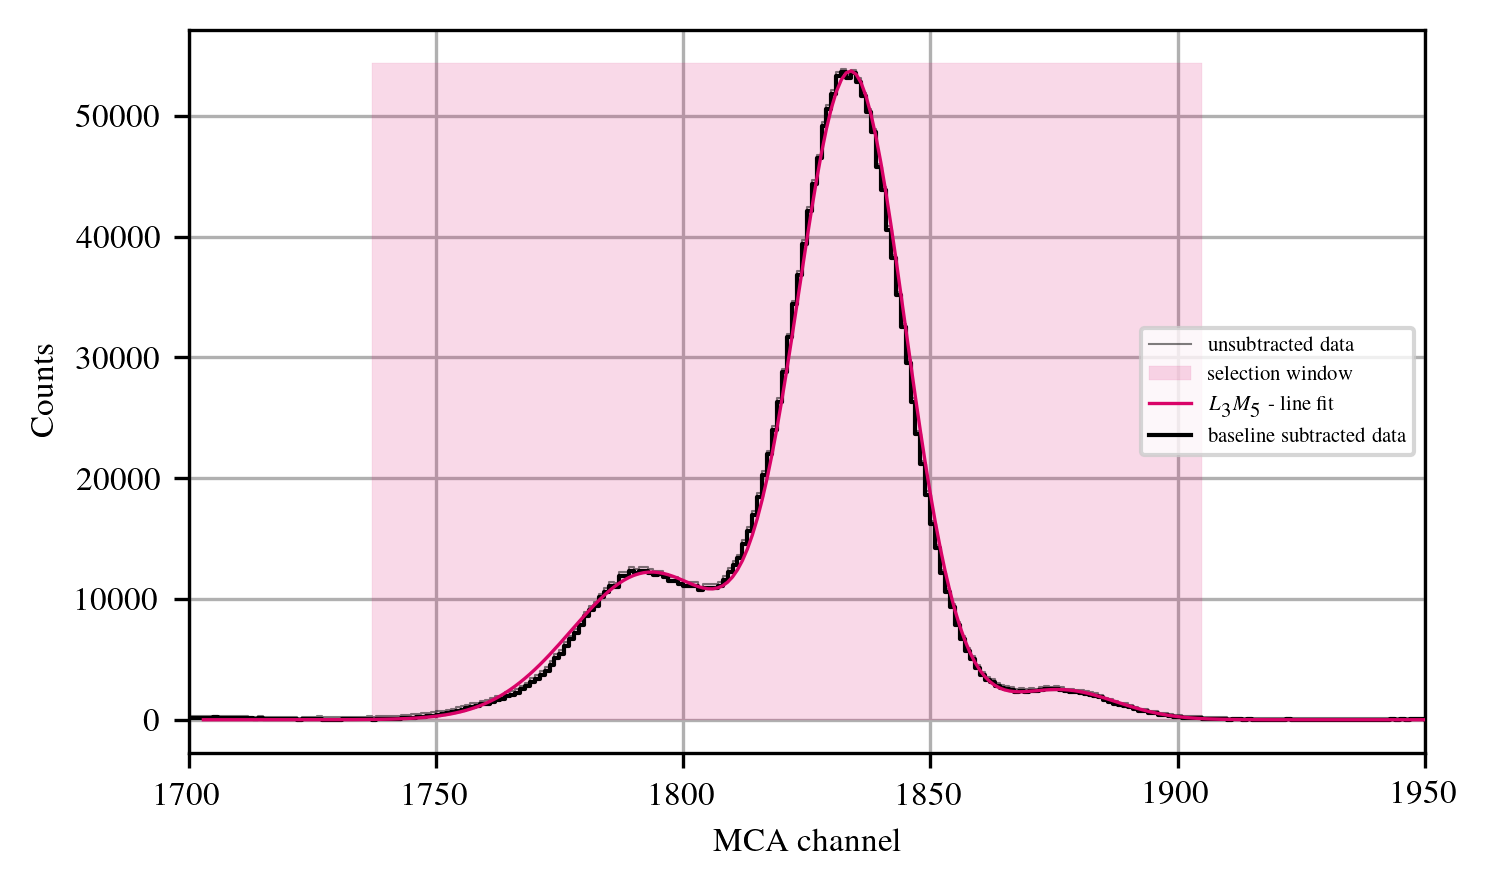

In [60]:
file_to_analyze = './/collected_data//2026_05_13//20260513-160638.vspc'

init_val1 = [[1800,7820,19]]
init_val2 = [[10500,1780,12,51800,1830,10,2200,1876,10]]
init_val3 = [[2000,3460,15]]
xlim1 = [7700,8000]
xlim2 = [1700,1950]
xlim3 = [3350,3550]
ylim1 = [0,2000]
ylim2 = []
ylim3 = [0,2300]
info1 = ['Americium', r'$\gamma_{2,0}$']
info2 = ['Neptunium', r'$L_3M_5$', 'test1','test2', 'test3']
info3 = ['Americium', r'$\gamma_{4,0}$']
gauss1 = ['single']
gauss2 = ['multi']
gauss3 = ['single']

# selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0s', gauss_ident=gauss1, s_flag=True, r_flag='roi_x')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0sf', gauss_ident=gauss1, s_flag=True, r_flag='roi_f')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0st', gauss_ident=gauss1, s_flag=True, r_flag='roi_t')

# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3s', gauss_ident=gauss3, s_flag=False, r_flag='roi_x')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3s', gauss_ident=gauss3, s_flag=True, r_flag='roi_x')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3sf', gauss_ident=gauss3, s_flag=True, r_flag='roi_f')
# selection_fitter_plotter(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3st', gauss_ident=gauss3, s_flag=True, r_flag='roi_t')

selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='2s', gauss_ident=gauss2, s_flag=True, r_flag='roi_x')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='2sf', gauss_ident=gauss2, s_flag=True, r_flag='roi_f')
selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='2st', gauss_ident=gauss2, s_flag=True, r_flag='roi_t')



# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='1', gauss_ident=gauss2)
# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3', gauss_ident=gauss3)